# House Price Prediction - Ridge, Lasso & Elastic Net

# Import Libraries

In [62]:
# Import libraries 
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

# Print version of each library
print(pd.__version__)
#print(plt.__version__)
print(sns.__version__)
print(np.__version__)

3.0.0
0.13.2
2.3.2


## 1. Load the Dataset

In [63]:
df = pd.read_csv('../Datasets/Housing.csv')

In [64]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 2. Split the Data into Training and Test Sets

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
# X: input features
# Y: Target 
X = df.drop('price', axis=1)
y = df['price']

In [67]:
# np.log1p(y) applies the transformation log(1 + y)
# The "+1" handles the edge case where y = 0 (log(0) is undefined)
y = np.log1p(y)

# We could use np.log(y) if we are certain no prices are 0

In [ ]:
# random state to replicate results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)
print("X_train Shape:",  X_train.shape)
print("X_test Shape:", X_test.shape)
print("Y_train Shape:", y_train.shape)
print("Y_test Shape:", y_test.shape)

X_train Shape: (381, 12)
X_test Shape: (164, 12)
Y_train Shape: (381,)
Y_test Shape: (164,)


## 3. Feature Engineering & Encoding

In [69]:
# Identify numerical and categoricla features
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
print("Numeric Features:", numeric_features)

categorical_features = X_train.select_dtypes(include=['str']).columns
print("Categorical Features:", categorical_features)

Numeric Features: Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='str')
Categorical Features: Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


7 categorical columns with binary yes/no values (plus furnishingstatus with 3 levels) will expand to 8 columns after OneHotEncoding(drop='first' removes one per feature to avoid the "dummy variable trap" perfect multicollinearity)

In [70]:
# Scale and Encode featues
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Scaler is Robust to outliers
scaler = RobustScaler()
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# KEY RULE
# .fit_transform() on train -> learns the scaling/encoding parameters FROM training data
# .transform()     on test  -> applies the SAME parameters to test data (no leakage!)
numeric_scaled = scaler.fit_transform(X_train[numeric_features])
numeric_scaled_test = scaler.transform(X_test[numeric_features])
categorical_encoded = encoder.fit_transform(X_train[categorical_features])
categorical_encoded_test = encoder.transform(X_test[categorical_features])

print("Numeric Scaled Shape:", numeric_scaled.shape)
print("Numeric Scaled Test Shape:", numeric_scaled_test.shape)
print("Categorical Encoded Shape:", categorical_encoded.shape)
print("Categorical Encoded Test Shape:", categorical_encoded_test.shape)

# ALTERNATIVE SCALERS:
# StandardScaler -> standardises to mean=0, std=1 (good when no outliers)
# MinMaxScaler   -> scales to a [0,1] range (good for neural networks)
#
# ALTERNATIVE ENCODERS:
# OrdinalEncoder -> assigns integer ranks (good when categories have natural order)
# pd.get_dummies() -> pandas built-in, simpler but less pipeline-friendly



Numeric Scaled Shape: (381, 5)
Numeric Scaled Test Shape: (164, 5)
Categorical Encoded Shape: (381, 8)
Categorical Encoded Test Shape: (164, 8)


In [71]:
# Concatenate numeric and categorical features
X_train_processed = np.concatenate((numeric_scaled, categorical_encoded), axis=1)
X_test_processed = np.concatenate((numeric_scaled_test, categorical_encoded_test), axis=1)

print("X_train Processed Shape:", X_train_processed.shape)
print("X_test Processed Shape:", X_test_processed.shape)

# Better Alternative:
# using ColumnTransformer()

X_train Processed Shape: (381, 13)
X_test Processed Shape: (164, 13)


All values are now numbers the model can train on this matrix.

Improvement, use Column transformer instead:

https://www.geeksforgeeks.org/machine-learning/using-columntransformer-in-scikit-learn-for-data-preprocessing/

# 4. Models

 **Regularization** adds a penalty to the loss function to discourage overly large coefficients,  producing simpler, more generalizable models.

> | Model | Penalty | Effect |
> |---|---|---|
> | Ridge | L2 (sum of squared coefficients) | Shrinks all coefficients, keeps all features |
> | Lasso | L1 (sum of absolute coefficients) | Can zero-out coefficients → automatic feature selection |
> | Elastic Net | L1 + L2 combined | Balance between Ridge and Lasso |

Guide: https://www.geeksforgeeks.org/machine-learning/implementation-of-lasso-ridge-and-elastic-net/

### 4.1 Ridge Regression

In [72]:
from sklearn.linear_model import Ridge

# Ridge Regression add Linear Regression with L2 regularization penalty
# Force to keep all coefficients small, reducing overfitting.
# alpha controls the strength of the regularization 
# If alpha = 0, then is plain Linear Regression (no penalty applied)
# If the alpha is high then stronger penalty, simplear model and may undefit
# If the alpha is low then weaker penalty, more complex model and may overfit.
Ridge_model  = Ridge(alpha = 10)
Ridge_model.fit(X_train_processed, y_train)
y_pred_Ridge = Ridge_model.predict(X_test_processed)

# Alternative: Use BayesionRidge which automatically estimate the best alpha, do not need tunning

In [73]:
# We reverse the Log transformation applied before
# This convert prediction back to teal money values for interpretability
y_pred_Ridge_real = np.expm1(y_pred_Ridge)   

In [74]:
# Only do this once:
# We also need to reverse the log transformation from y_test but only once and reuse it for the models below
y_test_real = np.expm1(y_test) 

In [75]:
# Preview of Predictions vd Real Prices
# Some error is expected
print("First 10:")
print('Predicted prices: \n', [int(i) for i in y_pred_Ridge_real[:10]])
print('Real prices: \n', [int(i) for i in y_test_real[:10]])        

First 10:
Predicted prices: 
 [5823556, 6037299, 6453882, 5173396, 4228235, 3227200, 2826192, 7395776, 2711938, 4381409]
Real prices: 
 [7069999, 4550000, 5599999, 6124999, 2939999, 3780000, 2449999, 7490000, 2939999, 6440000]


In [76]:
# Example prediction
# Unseen House prediction
new_house = pd.DataFrame([{'area': 5000, 'bedrooms': 3, 'bathrooms': 2,
'stories': 2,'parking':1, 'mainroad': 'yes', 'guestroom': 'no', 'basement': 'no',
'hotwaterheating': 'no', 'airconditioning': 'yes',
'prefarea': 'no', 'furnishingstatus': 'semi-furnished'}])

# Apply the same preprocessing pipeline to the new house data
new_house_numeric_scaled = scaler.transform(new_house[numeric_features])
new_house_categorical_encoded = encoder.transform(new_house[categorical_features])

new_house_processed = np.concatenate((new_house_numeric_scaled, new_house_categorical_encoded), axis=1)

predicted_price = Ridge_model.predict(new_house_processed)
predicted_price = np.expm1(predicted_price) # reverse log scale
print(predicted_price)

[5439438.42291617]


Almost the same value as the prediction with Linear Regression

In [77]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# We define a function to reuse the model evaluation
def evaluate_model(y_true, y_pred, model_name="Model"):
    r2  = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"R-squared:              {r2:.4f}")
    print(f"Mean Squared Error:     {mse:.4f}")
    print(f"Root Mean Sq Error:     {np.sqrt(mse):.4f}")
    print(f"Mean Absolute Error:    {mae:.4f}")
    print()

In [78]:
# Evaluate the Ridge Model test data
evaluate_model(y_test_real, y_pred_Ridge_real, "Ridge")

--- Ridge ---
R-squared:              0.6828
Mean Squared Error:     1291075670458.1921
Root Mean Sq Error:     1136255.1080
Mean Absolute Error:    816449.8542



In [79]:
# We can evaluate the training data only the check for Overfitting
# If Training R^2 > Test R^2 then there is overfitting as the model memorised the training data
# and cannot generalise well (Not the case here)
y_pred_Ridge_train = np.expm1(Ridge_model.predict(X_train_processed))
y_train_real = np.expm1(y_train)
evaluate_model(y_train_real, y_pred_Ridge_train, "Ridge (Train)")


--- Ridge (Train) ---
R-squared:              0.6743
Mean Squared Error:     1056361676385.4203
Root Mean Sq Error:     1027794.5692
Mean Absolute Error:    733838.7297



KEY OBSERVATION No overfitting:
Train R² (0.6743) is LOWER than Test R² (0.6828).  
It suggests the regularization (alpha=10) is slightly too strong and is underfitting: the model is being penalised so hard it cannot even fully learn the training data.  

This hints that a lower alpha might produce better results (which GridSearchCV will confirm later)  

RMSE of ~$1.1M on houses that likely range from ~$1.75M–$13M means errors
are proportionally significant. This is expected from a linear model on a
dataset with only 381 training samples.

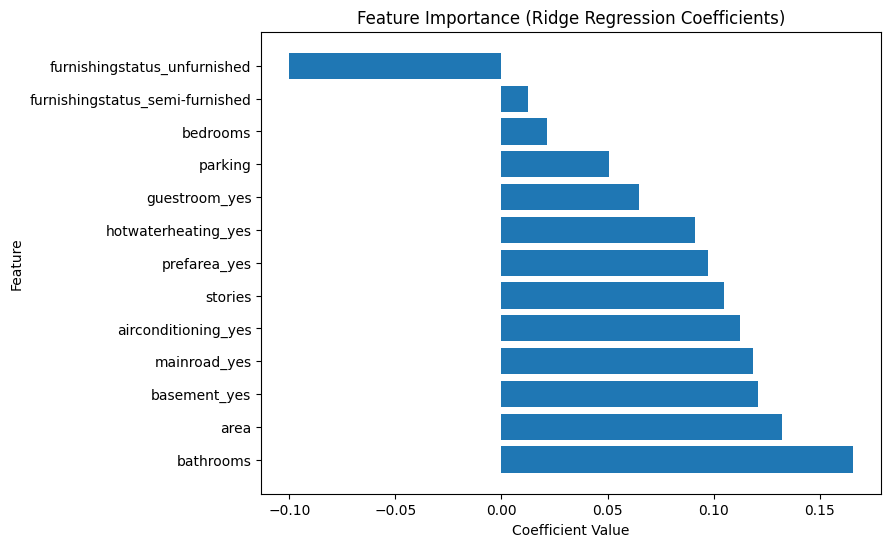

In [80]:
# Visualize feature importante
ridge_df = pd.DataFrame({})
ridge_coefficients = Ridge_model.coef_
ridge_df['Coefficients'] = ridge_coefficients
ridge_df['Feature'] = list(numeric_features) + list(encoder.get_feature_names_out(categorical_features))
ridge_df_sorted = ridge_df.sort_values(by = 'Coefficients', ascending = False)

plt.figure(figsize=(8,6))
plt.barh(ridge_df_sorted["Feature"], ridge_df_sorted["Coefficients"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Ridge Regression Coefficients)")
plt.show()

### 4.2 Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso

# The key difference between Ridge and Lasso is that Lasso can Shirk some coefficient to zero.
# This means Lasso performs automatic feature selection.
Lasso_model = Lasso(alpha = 0.01)
Lasso_model.fit(X_train_processed, y_train)
y_pred_Lasso = Lasso_model.predict(X_test_processed)

# Alternative: LassoCV to find automatically best alpha

In [82]:
# Log Transformation reversed
y_pred_Lasso_real = np.expm1(y_pred_Lasso)   

In [83]:
print("First 10:")
print('Predicted prices: \n', [int(i) for i in y_pred_Lasso_real[:10]])
print('Real prices: \n', [int(i) for i in y_test_real[:10]])        

First 10:
Predicted prices: 
 [5733583, 6267152, 6526429, 5236439, 4301347, 3284551, 2937181, 7211904, 2909022, 4315043]
Real prices: 
 [7069999, 4550000, 5599999, 6124999, 2939999, 3780000, 2449999, 7490000, 2939999, 6440000]


In [84]:
# New unseen house prediction with Lasso
predicted_price = Lasso_model.predict(new_house_processed)
predicted_price = np.expm1(predicted_price) # reverse log scale
print(predicted_price)

[5328344.6948368]


In [85]:
# Evaluate Lasso Model performance
evaluate_model(y_test_real, y_pred_Lasso_real,"Lasso")

--- Lasso ---
R-squared:              0.6419
Mean Squared Error:     1457594434523.5117
Root Mean Sq Error:     1207308.7569
Mean Absolute Error:    850015.0271



In [86]:
# We can evaluate the training data only the check for Overfitting
y_pred_Lasso_train = np.expm1(Lasso_model.predict(X_train_processed))
evaluate_model(y_train_real, y_pred_Lasso_train, "Lasso (Train)")


--- Lasso (Train) ---
R-squared:              0.6527
Mean Squared Error:     1126309424309.0996
Root Mean Sq Error:     1061277.2608
Mean Absolute Error:    751556.0675



KEY OBSERVATION Lasso performs WORSE than Ridge at these alpha values:  

R² drops from 0.6828 (Ridge) to 0.6419 (Lasso). Why?  
With alpha=0.01, Lasso is already zeroing out some features it considers
unimportant. If those features actually do carry signal, removing them
hurts prediction accuracy.  

Also note: Train R² (0.6527) > Test R² (0.6419) a small but normal gap,
suggesting very mild overfitting (the model learned training data slightly better
than it generalises). The gap is small enough not to be a concern.
The real question is: which features did Lasso zero out?

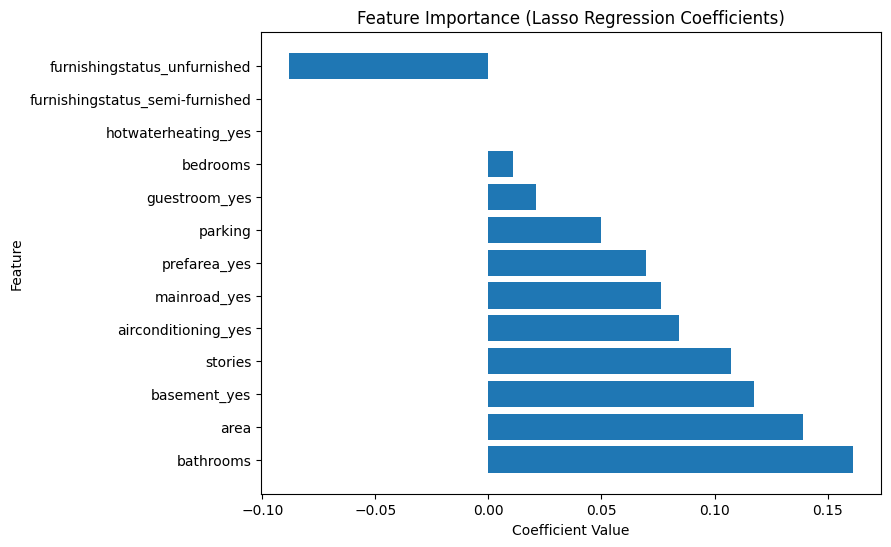

In [87]:
Lasso_df = pd.DataFrame({})
Lasso_df['Coefficients'] = Lasso_model.coef_
Lasso_df['Feature'] = list(numeric_features) + list(encoder.get_feature_names_out(categorical_features))
Lasso_df_sorted = Lasso_df.sort_values(by = 'Coefficients', ascending = False)

# Some coefficients will appeared as empty since there were shrink to zero
plt.figure(figsize=(8,6))
plt.barh(Lasso_df_sorted["Feature"], Lasso_df_sorted["Coefficients"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Lasso Regression Coefficients)")
plt.show()

### 4.3 Elastic Net Regression

In [95]:
from sklearn.linear_model import ElasticNet

# Elastic Net combina both, Ridge and Lasso penalties
# This give us the best of both worlds
# - Ridge: handle correlated features well
# - Lasso: can zero out irrelevant features

# 2 parameter to tune:
# 1. alpha: the regularization strength
# 2. L1_ratio : Mix between L1 and L2, where 0: pure Ridge, 1: pure Lasso and 0.5: equal mix of both
ENet = ElasticNet(alpha = 0.01, l1_ratio=0.5)
ENet.fit(X_train_processed, y_train)
y_pred_ENet = ENet.predict(X_test_processed)

# Alternative: ElasticNetCV tune both alpha and L1 ratio automatically

In [96]:
# Reverse the Log transformation prediction
y_pred_ENet_real = np.expm1(y_pred_ENet)

In [97]:
print("First 10:")
print('Predicted prices: \n', [int(i) for i in y_pred_ENet_real[:10]])
print('Real prices: \n', [int(i) for i in y_test_real[:10]])        

First 10:
Predicted prices: 
 [5828998, 6116087, 6487819, 5210650, 4252808, 3251034, 2857406, 7342577, 2803738, 4345313]
Real prices: 
 [7069999, 4550000, 5599999, 6124999, 2939999, 3780000, 2449999, 7490000, 2939999, 6440000]


In [98]:
predicted_price = ENet.predict(new_house_processed)
predicted_price = np.expm1(predicted_price) # reverse log scale
print(predicted_price)

[5403810.21141458]


In [99]:
evaluate_model(y_test_real, y_pred_ENet_real,"ElasticNet")

--- ElasticNet ---
R-squared:              0.6668
Mean Squared Error:     1356124245063.7236
Root Mean Sq Error:     1164527.4772
Mean Absolute Error:    829706.2695



In [100]:
# We can evaluate the training data only the check for Overfitting
y_pred_ENet_train = np.expm1(ENet.predict(X_train_processed))
evaluate_model(y_train_real, y_pred_ENet_train, "ElasticNet (Train)")


--- ElasticNet (Train) ---
R-squared:              0.6661
Mean Squared Error:     1082715515210.0791
Root Mean Sq Error:     1040536.1672
Mean Absolute Error:    738252.0744



KEY OBSERVATION  Almost identical Train and Test R² (0.6661 vs 0.6668):
This is a hallmark of a well-regularized model. The gap between train and test
is essentially zero the model generalises about as well as it fits training data.  

This is the BEST overfitting indicator of all three models.
Performance sits between Ridge (0.6828) and Lasso (0.6419) (as expected),
since Elastic Net blends both penalties. At alpha=0.1, it is applying stronger
regularization than Lasso (0.01), which explains the slightly lower raw R².  


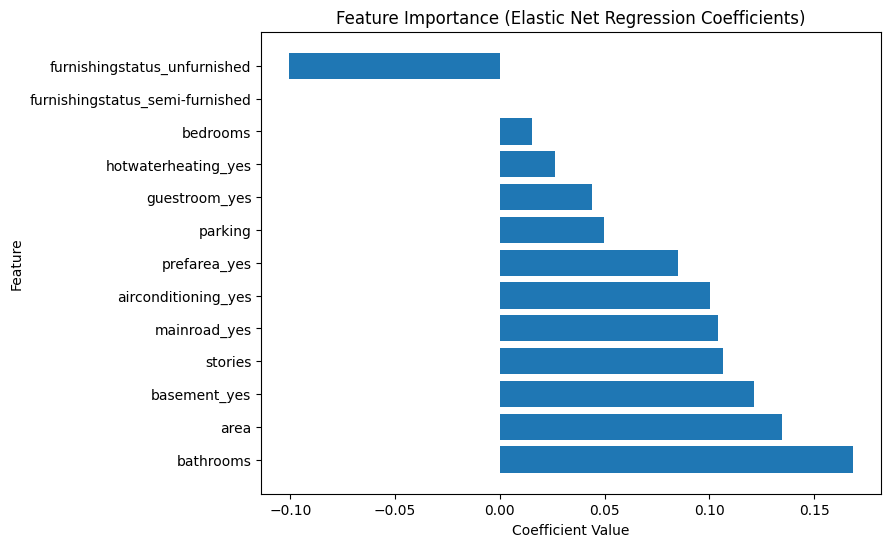

In [102]:
ENet_df = pd.DataFrame({})
ENet_coefficients = ENet.coef_
ENet_df['Coefficients'] = ENet_coefficients
ENet_df['Feature'] = list(numeric_features) + list(encoder.get_feature_names_out(categorical_features))
ENet_df_sorted = ENet_df.sort_values(by = 'Coefficients', ascending = False)

plt.figure(figsize=(8,6))
plt.barh(ENet_df_sorted["Feature"], ENet_df_sorted["Coefficients"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Elastic Net Regression Coefficients)")
plt.show()

## 5. Hyperparameter Tuning with GridSearchCV

So far we chose alpha values manually but we want to discover the best alpha value were our model can perform better than our baseline (Linear Regression).

For that we use the GridSearchCV approach which:

GRID SEARCH: We define a grid of hyperparameter values to try.
  param_R_L tries 6 different alpha values for Ridge and Lasso.
  param_ENet tries 5 alphas × 5 l1_ratios = 25 combinations for Elastic Net.
  
CROSS-VALIDATION (cv=5): For each combination, the training data is split into
  5 folds. The model trains on 4 folds and validates on 1, cycling through all 5.
  The average score across folds is used to compare combinations.
  This gives a more reliable estimate than a single train/validation split.

*An Alternative to this is the RandomizedSearchCV which samples random combinations of the parameters instead of trying them all. IS much more faster when there are many parameters and combinations to try.

In [103]:
from sklearn.model_selection import GridSearchCV

param_R_L = {
    'alpha' : [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

param_ENet = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

### 5.1 Tune Ridge

In [104]:
# GridSearchCV will try all 6 alpha values with 5-fold CV = 30 training runs total
# Keeps track of the best combination gave
grid_search_Ridge = GridSearchCV(Ridge_model, param_R_L, cv=5)
grid_search_Ridge.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge(alpha=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexe

In [108]:
# Print the best hyperparameters found by each method
# .best_estimator_ the model with the highest cross-validation score
# .best_params_ the hyperparameters that achieved the best score

Best_Ridge_model = grid_search_Ridge.best_estimator_
print(f"Best estimator: {Best_Ridge_model}")
print(f"Best hyperparameters: {grid_search_Ridge.best_params_}")

Best estimator: Ridge(alpha=1)
Best hyperparameters: {'alpha': 1}


In [109]:
y_test_Best_Ridge_model = Best_Ridge_model.predict(X_test_processed)
y_test_Best_Ridge_real = np.expm1(y_test_Best_Ridge_model)

In [110]:
evaluate_model(y_test_real, y_test_Best_Ridge_real, "Ridge (Tuned)")

--- Ridge (Tuned) ---
R-squared:              0.6902
Mean Squared Error:     1260931076465.2346
Root Mean Sq Error:     1122911.8739
Mean Absolute Error:    812754.0048



Best alpha: 1 (original was 10 we were over-regularizing)  
Tuned R²: 0.6902 vs baseline 0.6828  = improvement of +0.0074  
Tuned RMSE: 1,122,911 vs 1,136,255 = ~$13,000 less average error

### 5.2 Tune Lasso

In [112]:
grid_search_Lasso = GridSearchCV(Lasso_model, param_R_L, cv=5)
grid_search_Lasso.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso(alpha=0.01)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter inde

In [113]:
Best_Lasso_model = grid_search_Lasso.best_estimator_
print(f"Best hyperparameters: {grid_search_Lasso.best_params_}")
print(f"Best estimator: {Best_Lasso_model}")

Best hyperparameters: {'alpha': 0.0001}
Best estimator: Lasso(alpha=0.0001)


In [114]:
y_test_Best_Lasso_model = Best_Lasso_model.predict(X_test_processed)
y_test_Best_Lasso_real = np.expm1(y_test_Best_Lasso_model)

In [115]:
evaluate_model(y_test_real, y_test_Best_Lasso_real, "Lasso (Tuned)")

--- Lasso (Tuned) ---
R-squared:              0.6906
Mean Squared Error:     1259199191661.7366
Root Mean Sq Error:     1122140.4510
Mean Absolute Error:    813209.9692



Best alpha: 0.0001 (the SMALLEST value in our grid nearly zero regularization)  
Tuned R²: 0.6906 vs baseline 0.6419 = massive improvement of +0.0487  
Tuned RMSE: 1,122,140 vs 1,207,308 = ~$85,000 less average error

### 5.3 Tune Elastic Net

In [116]:
# This tries 5 × 5 = 25 hyperparameter combinations, each with 5-fold CV = 125 runs
# Elastic Net tuning takes longer than Ridge/Lasso because of the extra l1_ratio dimension

grid_search_ENet = GridSearchCV(ENet, param_ENet, cv=5)
grid_search_ENet.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet(alpha=0.01)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...], 'l1_ratio': [0.1, 0.3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [117]:
# Print the best hyperparameters found by each method
Best_ENet = grid_search_ENet.best_estimator_
print(f"Best hyperparameters: {grid_search_ENet.best_params_}")
print(f"Best estimator: {Best_ENet}")

Best hyperparameters: {'alpha': 0.001, 'l1_ratio': 0.3}
Best estimator: ElasticNet(alpha=0.001, l1_ratio=0.3)


In [118]:
y_test_Best_ENet = Best_ENet.predict(X_test_processed)
y_test_Best_ENet_real = np.expm1(y_test_Best_ENet)

In [119]:
evaluate_model(y_test_real, y_test_Best_ENet_real, "ElasticNet (Tuned)")

--- ElasticNet (Tuned) ---
R-squared:              0.6899
Mean Squared Error:     1262246878733.1370
Root Mean Sq Error:     1123497.6096
Mean Absolute Error:    812896.1833




Best: alpha=0.001, l1_ratio=0.3 (30% Lasso + 70% Ridge character)  
Tuned R²: 0.6899 vs baseline 0.6668 = improvement of +0.0231  
Tuned RMSE: 1,123,497 vs 1,164,527 = ~$41,000 less average error  

l1_ratio=0.3 means the tuned Elastic Net is more Ridge-like than Lasso-like  
This makes sense given the Lasso finding above the dataset benefits more from  
Ridge's "keep everything, shrink gently" approach than Lasso's feature elimination  
Low alpha (0.001) confirms minimal regularization is preferred on this small dataset  

## 6. Final Results Comparison

In [ ]:
# Helper function to create a tbale of all results obtained
def collect_metrics(y_true, y_pred, model_name="Model"):
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    return {
        "Model": model_name,
        "R²":    round(r2, 4),
        "MSE":   round(mse, 4),
        "RMSE":  round(np.sqrt(mse), 4),
        "MAE":   round(mae, 4)
    }

results = [
    collect_metrics(y_test_real, y_test_Best_ENet_real, "Elastic Net (Tuned)"),
    collect_metrics(y_test_real, y_test_Best_Lasso_real, "Lasso (Tuned)"),
    collect_metrics(y_test_real, y_test_Best_Ridge_real, "Ridge (Tuned)"),
]

df_results = pd.DataFrame(results).set_index("Model")
df_results

,R²,MSE,RMSE,MAE
Model,,,,
Elastic Net (Tuned),0.6899,1.262247e+12,1.123498e+06,812896.1833
Lasso (Tuned),0.6906,1.259199e+12,1.122140e+06,813209.9692
Ridge (Tuned),0.6902,1.260931e+12,1.122912e+06,812754.0048


The differences are in the 4th decimal place, statistically negligible.  
This convergence happens because all three models found very similar solutions:  
very low alpha (minimal regularization). On a small, clean, low-dimensional dataset with all informative features, regularization offers limited benefit.

# Next Steps

try these models to potentially improve performance further:
- Random Forest
- Gradient Boost
- XGBoost 
- SVR

They can capturer non linear patters that were miss.